In [12]:
!unzip -q crop_capstone.zip
%cd crop_capstone

unzip:  cannot find or open crop_capstone.zip, crop_capstone.zip.zip or crop_capstone.zip.ZIP.
[Errno 2] No such file or directory: 'crop_capstone'
/content/crop_capstone


In [13]:
!pip install -q streamlit

In [14]:
!python src/eda.py

[data] loaded crop_data.csv: (2200, 8)
Raw shape: (2200, 8)
Duplicate rows: 0
Missing values per column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
Out-of-range (impossible) values: {'N': 0, 'P': 0, 'K': 0, 'temperature': 0, 'humidity': 0, 'ph': 0, 'rainfall': 0}
Describe (raw):
             N        P        K  temperature  humidity       ph  rainfall
count  2200.00  2200.00  2200.00      2200.00   2200.00  2200.00   2200.00
mean     50.55    53.36    48.15        25.62     71.48     6.47    103.46
std      36.92    32.99    50.65         5.06     22.26     0.77     54.96
min       0.00     5.00     5.00         8.83     14.26     3.50     20.21
25%      21.00    28.00    20.00        22.77     60.26     5.97     64.55
50%      37.00    51.00    32.00        25.60     80.47     6.43     94.87
75%      84.25    68.00    49.00        28.56     89.95     6.92    124.27
max     140.00   145.00   2

In [15]:
!python src/train.py

[data] loaded crop_data.csv: (2200, 8)
Logistic Regression {'best_params': {'C': 100}, 'cv_f1_macro': np.float64(0.9776), 'test_accuracy': 0.9841, 'test_precision': 0.9852, 'test_recall': 0.9841, 'test_f1': 0.984, 'test_roc_auc': np.float64(0.9999)}
KNN {'best_params': {'n_neighbors': 5, 'weights': 'distance'}, 'cv_f1_macro': np.float64(0.968), 'test_accuracy': 0.9818, 'test_precision': 0.9829, 'test_recall': 0.9818, 'test_f1': 0.9816, 'test_roc_auc': np.float64(0.9987)}
Decision Tree {'best_params': {'max_depth': None, 'min_samples_leaf': 1}, 'cv_f1_macro': np.float64(0.9852), 'test_accuracy': 0.9795, 'test_precision': 0.9806, 'test_recall': 0.9795, 'test_f1': 0.9794, 'test_roc_auc': np.float64(0.9893)}

SELECTED: Logistic Regression
{
  "n_test": 440,
  "n_errors": 7,
  "top_confusions": {
    "rice->jute": 3,
    "lentil->mothbeans": 1,
    "maize->cotton": 1,
    "mothbeans->lentil": 1,
    "pigeonpeas->blackgram": 1
  },
  "weakest_classes": {
    "rice": 0.919,
    "jute": 0.93,


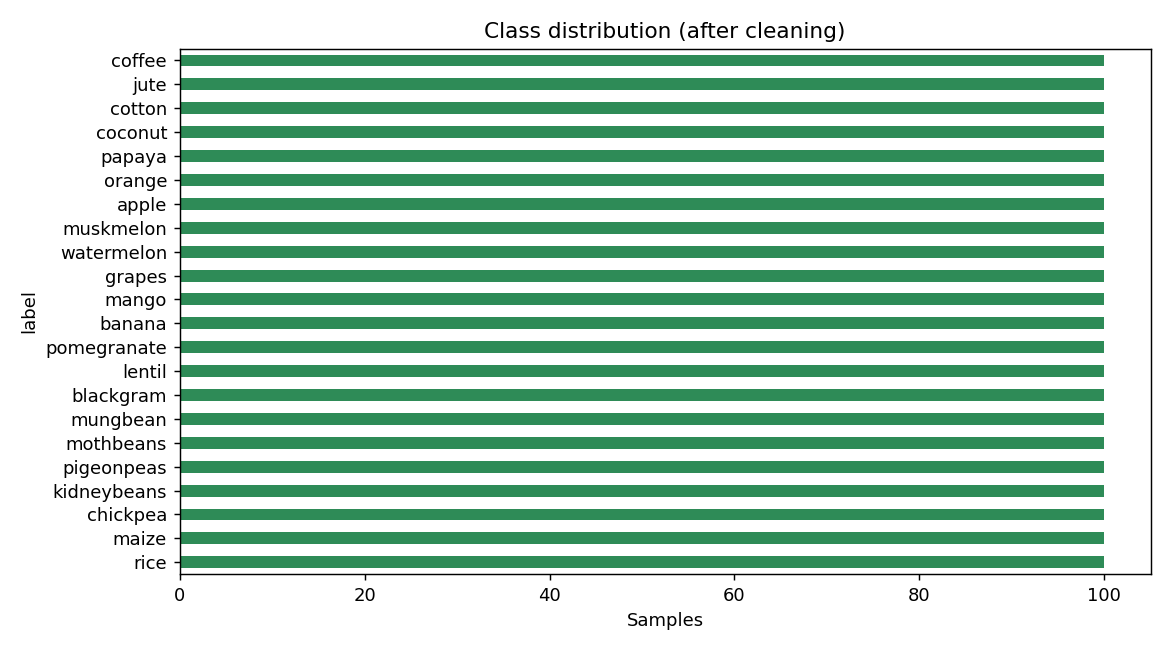

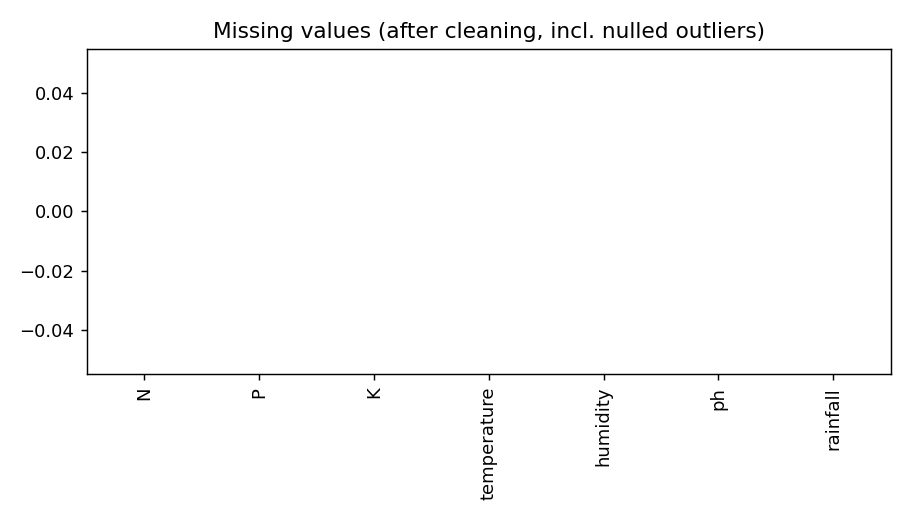

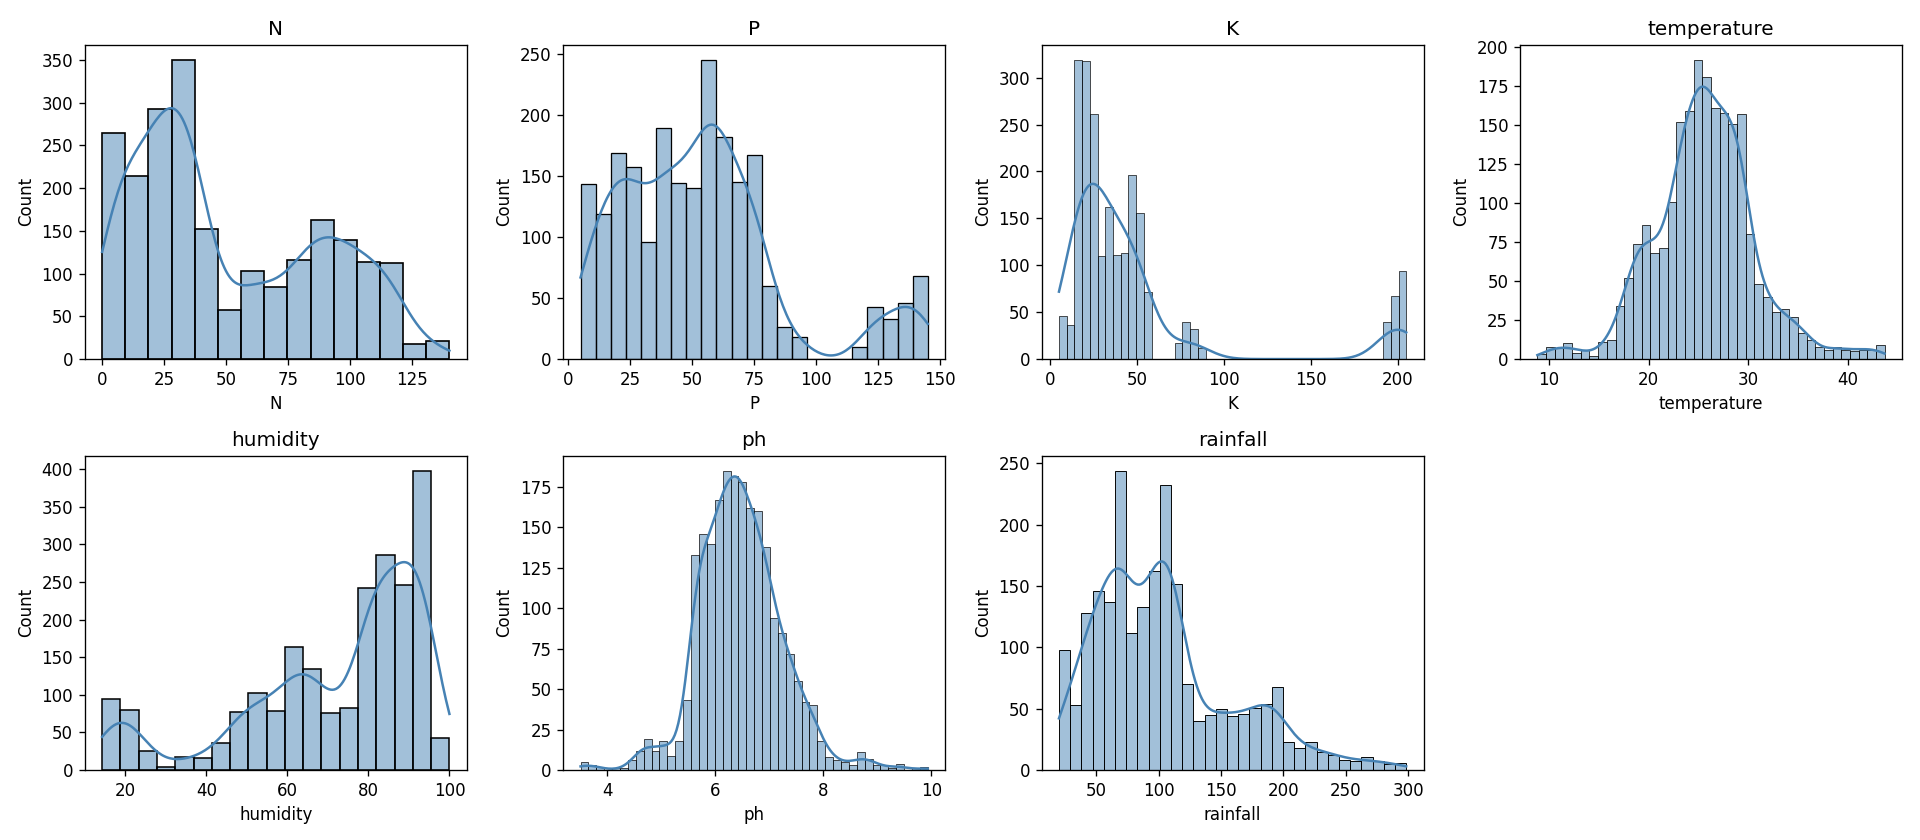

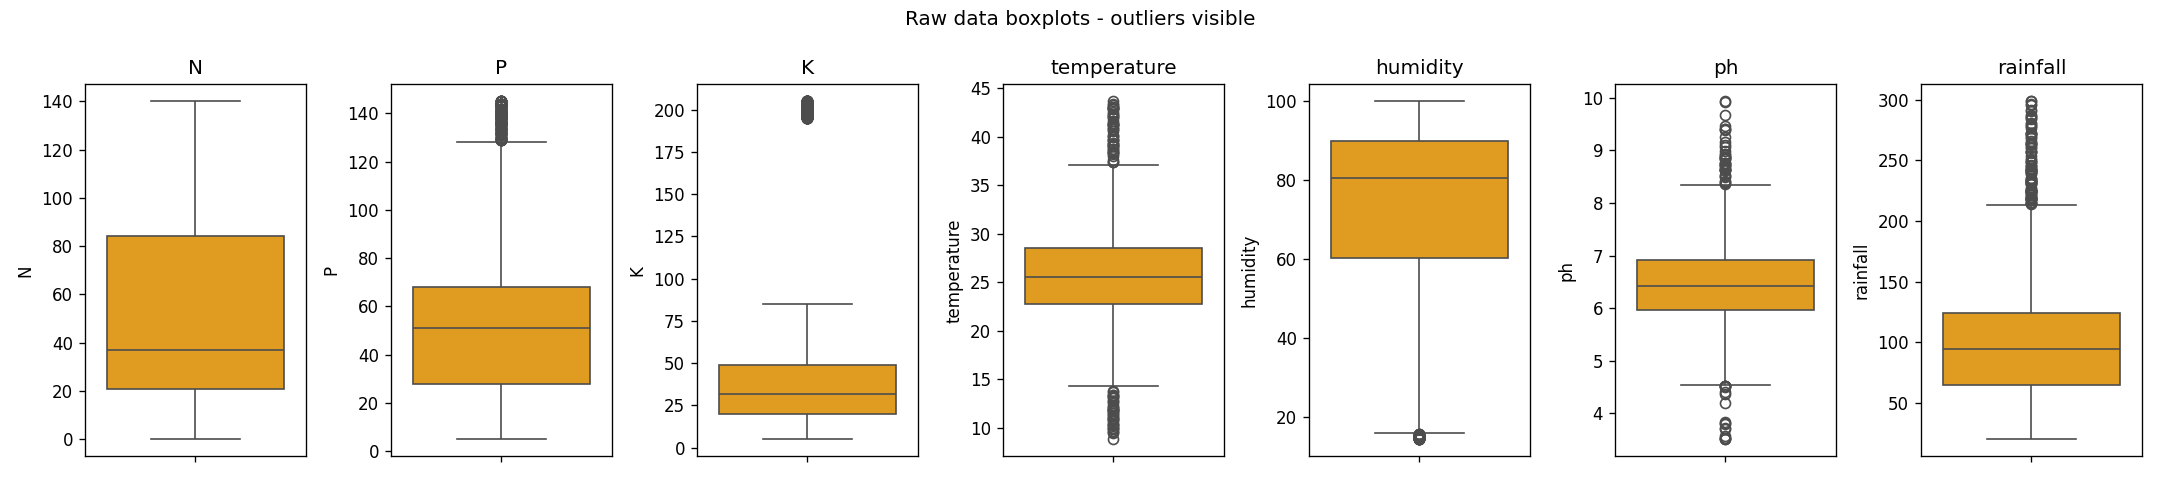

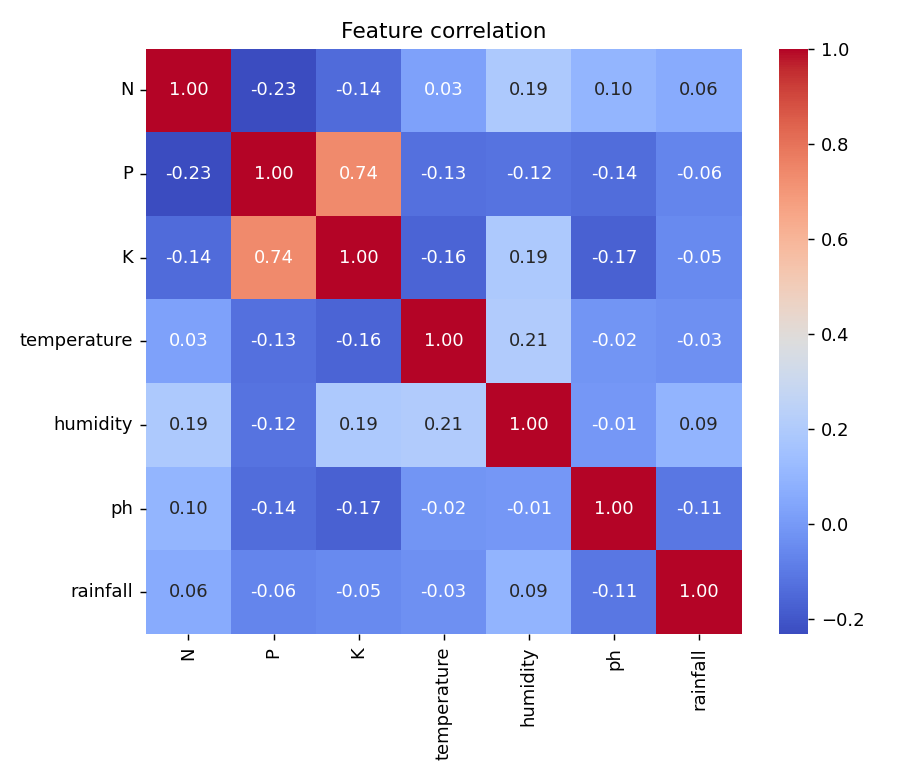

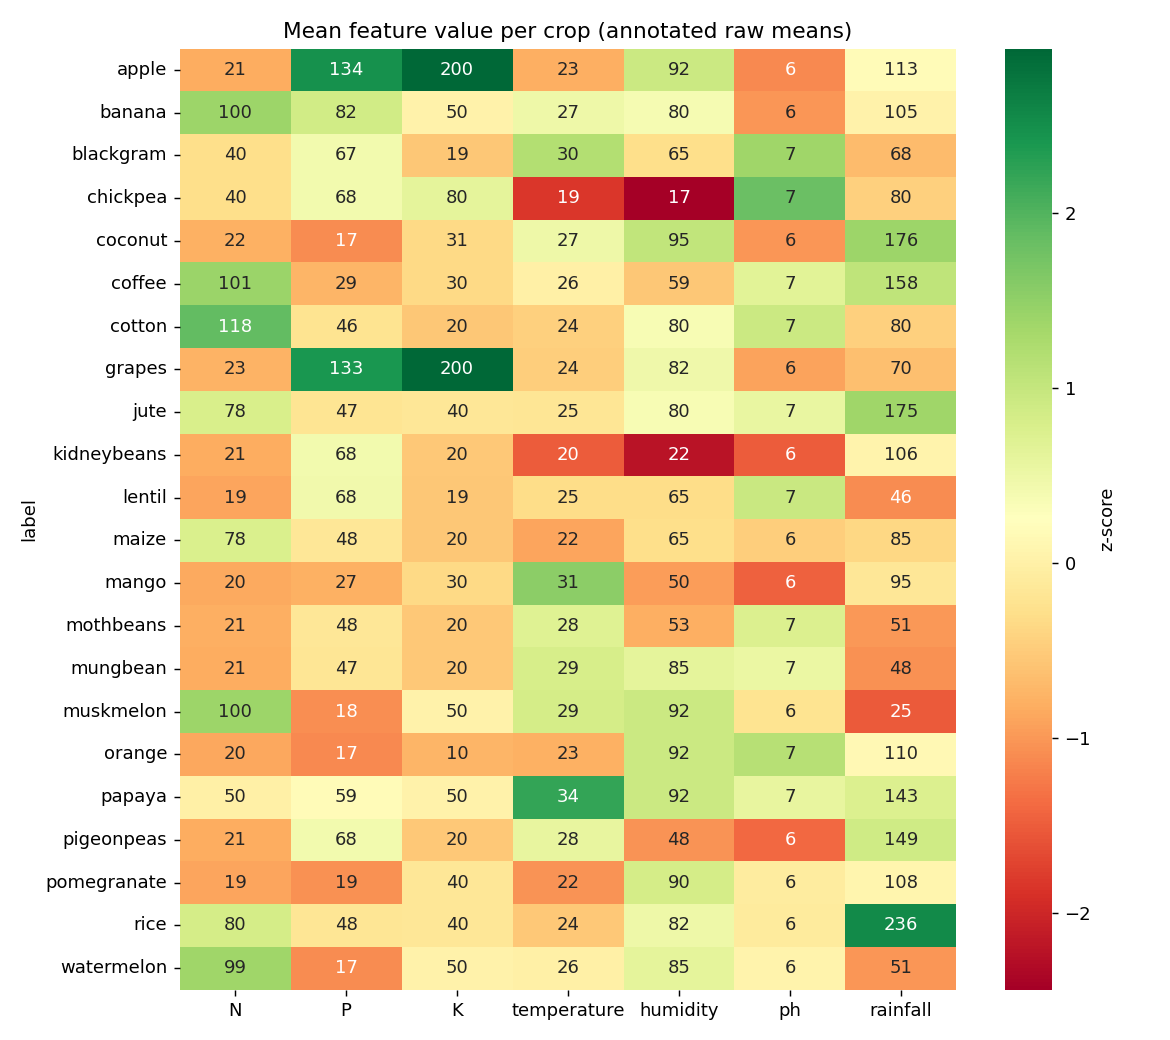

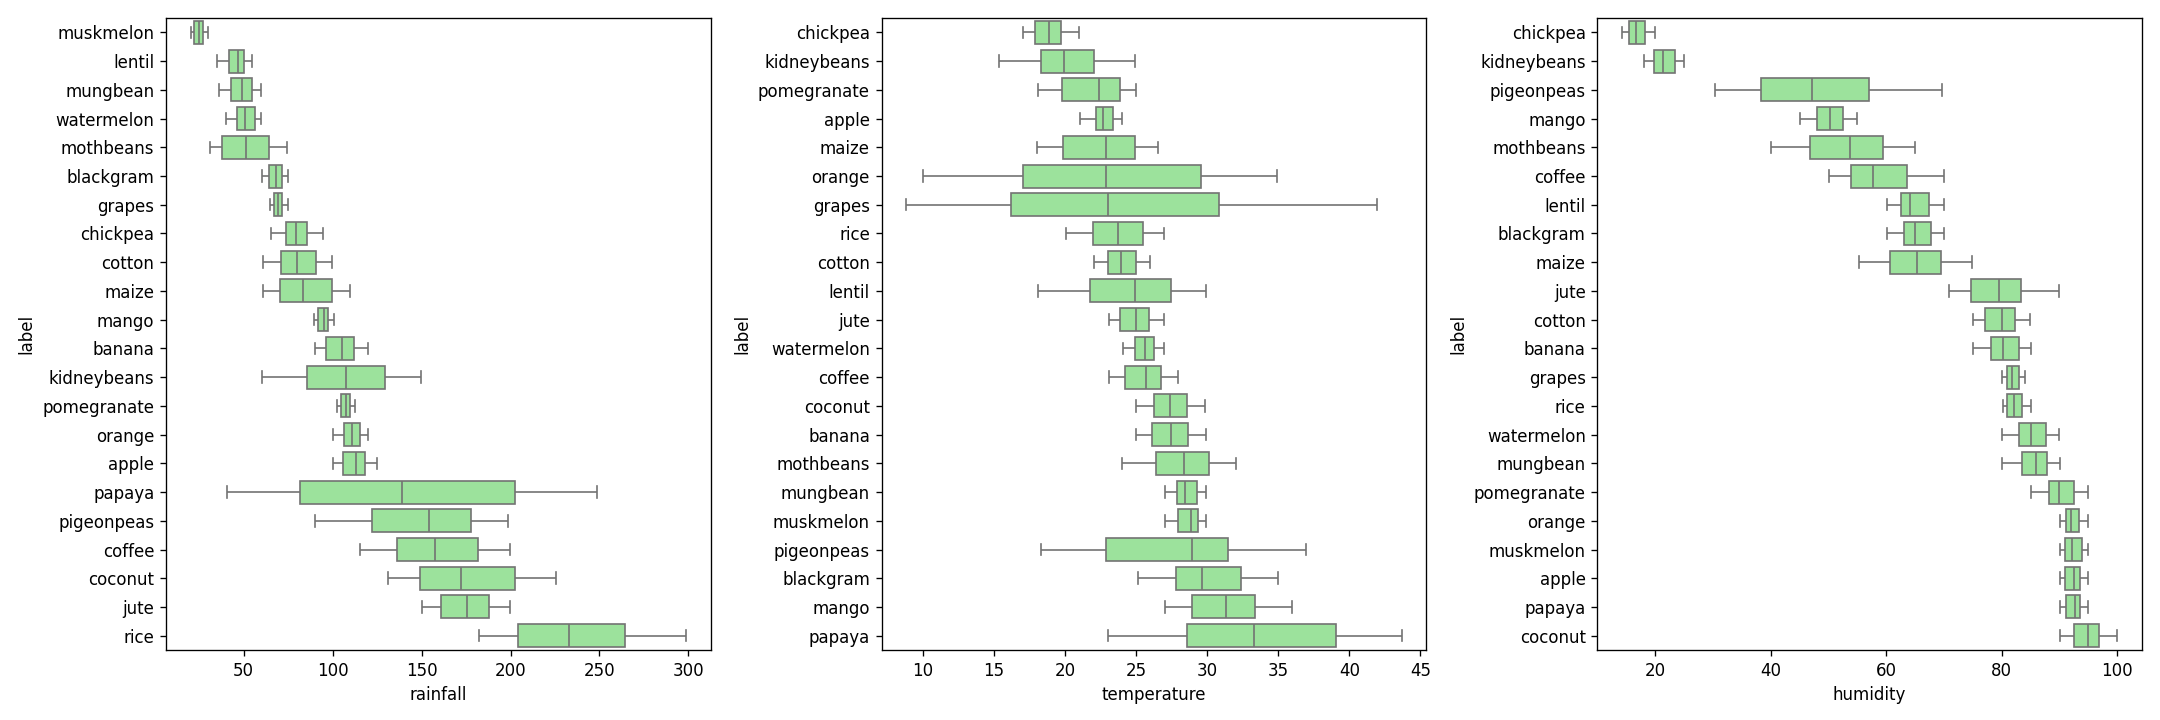

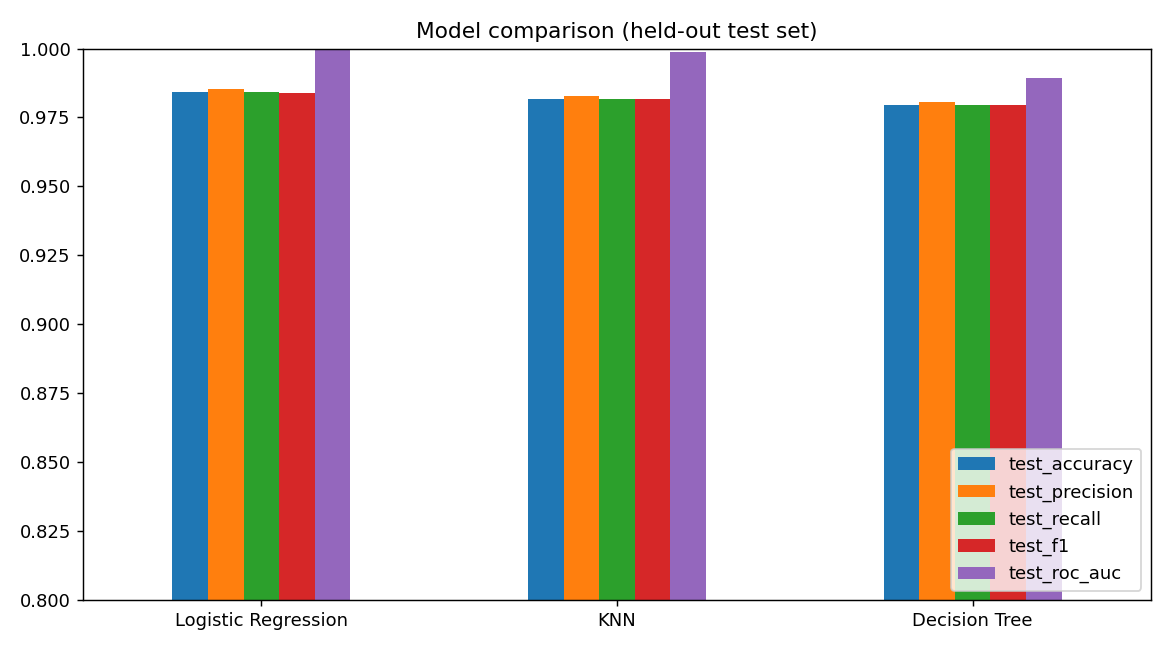

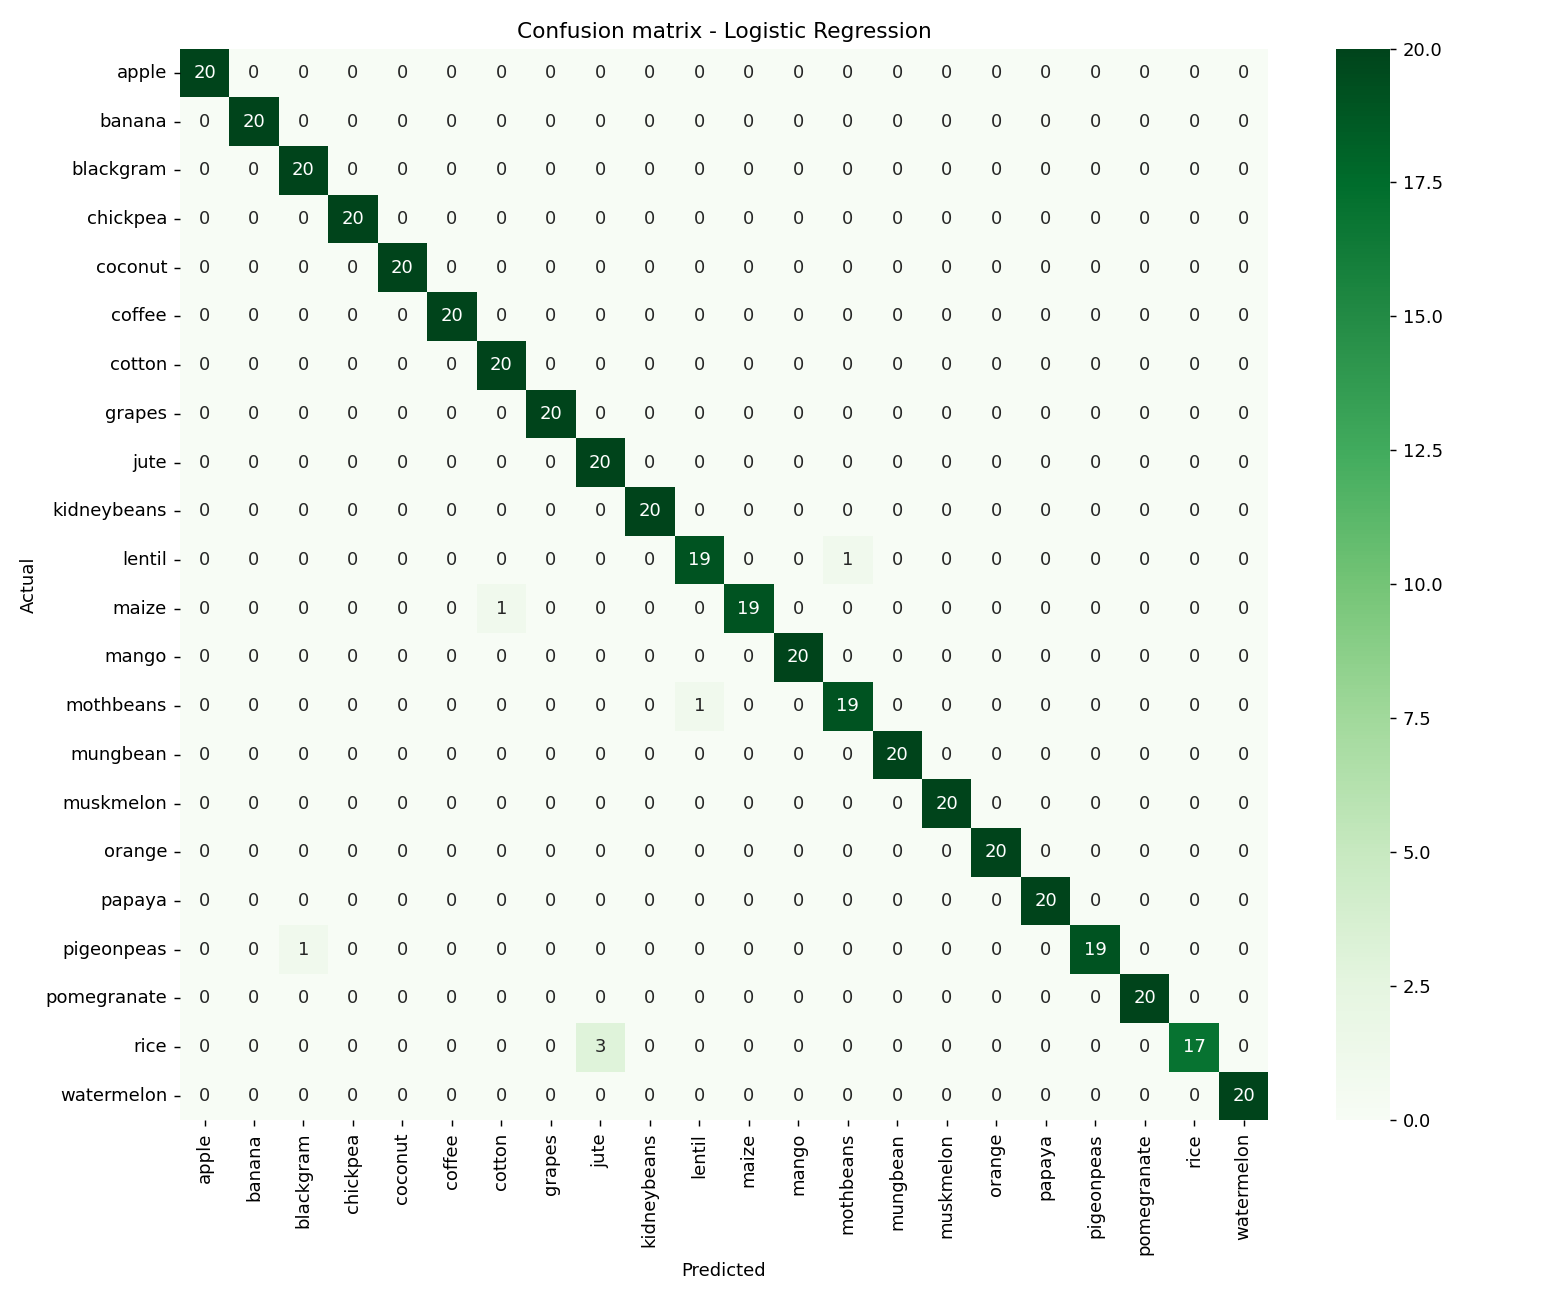

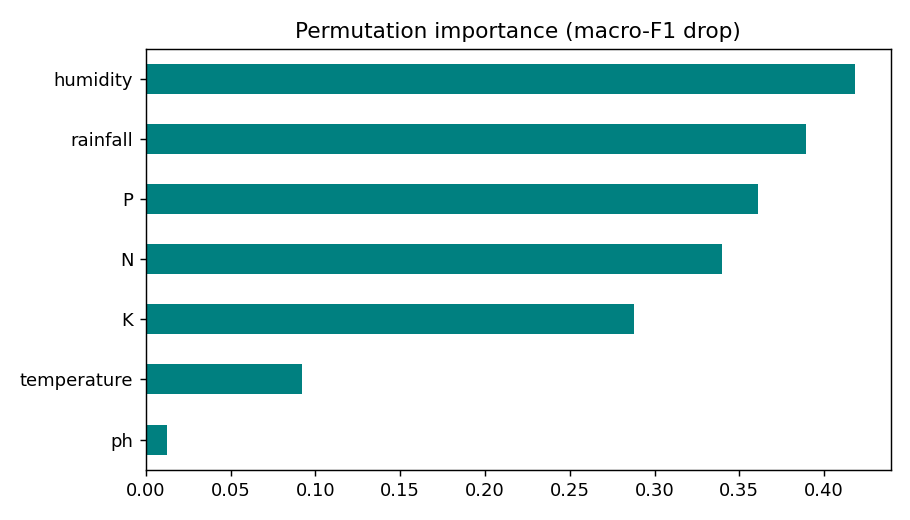

In [16]:
from IPython.display import Image, display
import glob
for f in sorted(glob.glob("reports/figures/*.png")):
    display(Image(f))

In [17]:
print(open("reports/classification_report.txt").read())
print(open("reports/eda_summary.txt").read())

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      0.95      0.95        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      0.95      0.95        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

In [18]:
import sys, joblib, pandas as pd
sys.path.insert(0, "src")
from preprocessing import FEATURES

model = joblib.load("models/crop_model.joblib")
sample = dict(N=80, P=48, K=40, temperature=24, humidity=82, ph=6.4, rainfall=236)
X = pd.DataFrame([sample], columns=FEATURES)
proba = model.predict_proba(X)[0]
top = proba.argsort()[::-1][:5]
for i in top:
    print(f"{model.classes_[i]:12s} {proba[i]:.1%}")

rice         99.5%
jute         0.5%
pigeonpeas   0.0%
papaya       0.0%
coconut      0.0%


In [39]:
!npm install -q localtunnel
!streamlit run app/streamlit_app.py &>/content/logs.txt &
import urllib
print("Password:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode().strip())
!npx localtunnel --port 8501 --subdomain my-crop-suitability

⠙⠹⠸⠼⠴⠦
up to date, audited 23 packages in 814ms
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠦Password: 104.196.217.3
⠙your url is: https://my-crop-suitability.loca.lt
^C
